### 1.load the Fashion-MNIST dataset 加载数据集

In [ ]:
import numpy as np
import tensorflow as tf

In [ ]:
(X_train_full,y_train_full),(X_test,y_test) = tf.keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


看一下数据集

In [ ]:
print(X_train_full.shape)   #(60000, 28, 28)
print(y_train_full.shape)   #(60000,)
print(X_test.shape)         #(10000, 28, 28)
print(y_test.shape)       #(10000,)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [ ]:
print(X_train_full[0])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0
    0   1   4   0   0   0   0   1   1   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62
   54   0   0   0   1   3   4   0   0   3]
 [  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134
  144 123  23   0   0   0   0  12  10   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 155 236 207 178
  107 156 161 109  64  23  77 130  72  15]
 [  0   0   0   0   0   0   0   0   0   0   0   1   0  69 207 223 218 216
  216 163 127 121 122 146 141  88 172  66]
 [  0   0   0   0   0   0   0   0   0   1   1   1   0 200 232 23

In [ ]:
import matplotlib.pyplot as plt
# Jupyter notebook 加这行，图片直接内嵌显示
%matplotlib inline

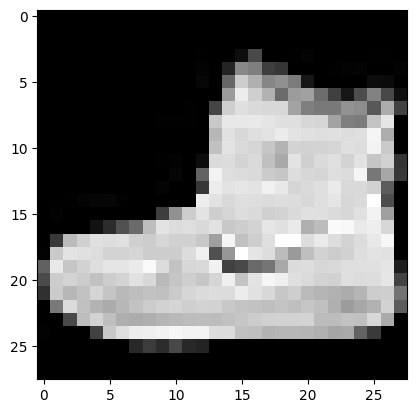

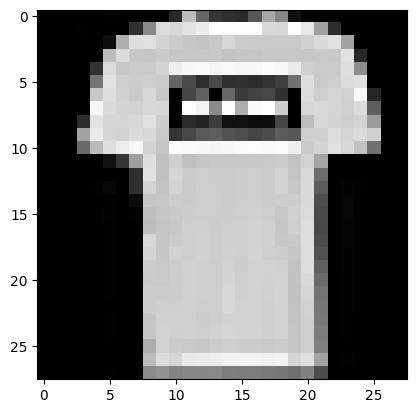

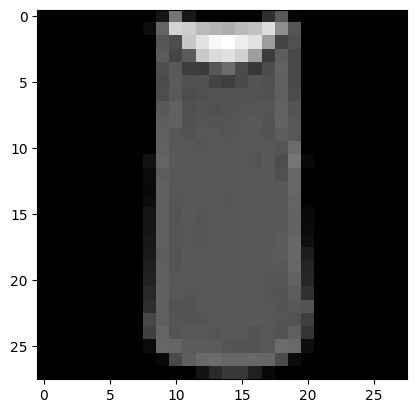

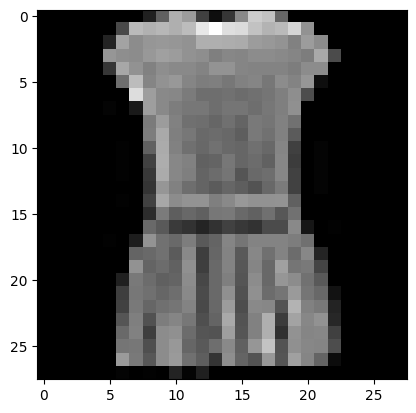

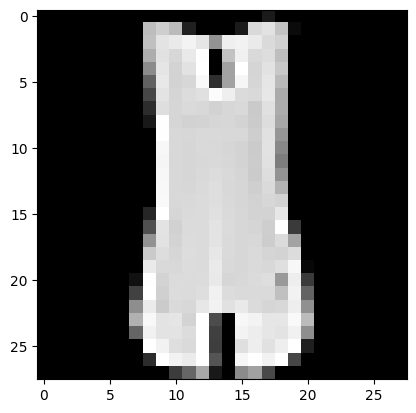

In [ ]:
for i in range(5):
  img = X_train_full[i]
  plt.imshow(img,cmap = "gray")
  plt.show()

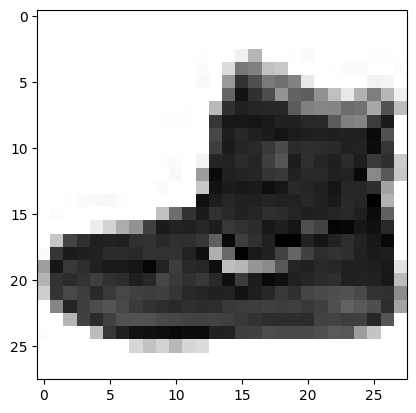

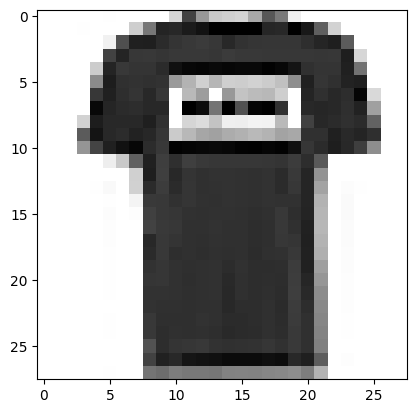

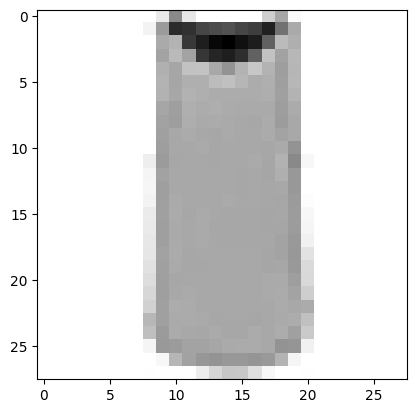

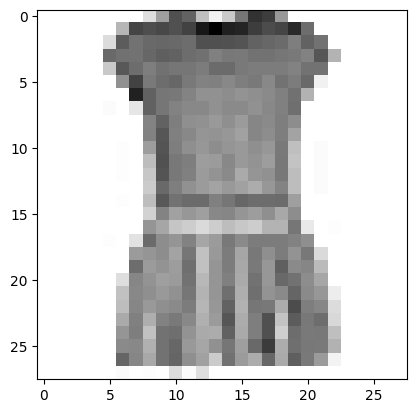

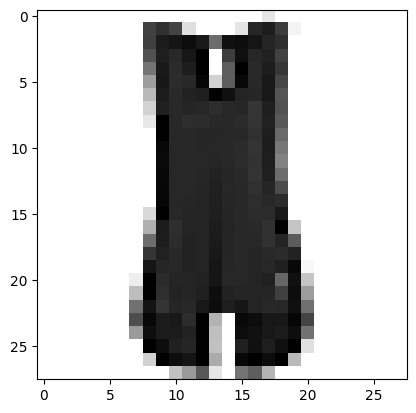

In [ ]:
for i in range(5):
  img = X_train_full[i]
  plt.imshow(img,cmap = "gray_r")
  plt.show()

### Step 2: Slice Training Data per Experiment | 按实验切分训练集

In [ ]:
X_valid, X_train = X_train_full[:5000] / 255.0, X_train_full[5000:] / 255.0
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]
X_test = X_test / 255.0

In [ ]:
!pip install PyGithub

In [ ]:
from github import Github, GithubException, Auth
from google.colab import userdata
# Github：主客户端，用来连 GitHub API
# GithubException：捕获 API 错误（如 404、403）
# Auth：新版认证方式，用来传 token

# GitHub Credentials and Targeting
# 从 Colab Secrets 读取名为 STUDENT_TOKEN 的 GitHub Personal Access Token。
# 需在 Colab 左侧 🔑 Secrets 里提前添加。
STUDENT_TOKEN = userdata.get('STUDENT_TOKEN')
REPO_NAME = "nikk909/mds7-YueMa"
TARGET_FOLDER = "week-10-12-ai"

# Authenticate with GitHub (Updated Auth Method)
auth = Auth.Token(STUDENT_TOKEN)
g = Github(auth=auth)
repo = g.get_repo(REPO_NAME)
print(f"Authenticated to repository: {repo.full_name}")


Authenticated to repository: nikk909/mds7-YueMa


In [ ]:
import os
from google.colab import _message
import json

# 要上传的本地文件名，必须和 Colab 当前目录里的文件名一致
NOTEBOOK_NAME = "The_Green_AI_Trade-Off.ipynb"

# 先把当前 notebook 保存到 /content
notebook = _message.blocking_request('get_ipynb', timeout_sec=10)['ipynb']
with open(NOTEBOOK_NAME, "w", encoding="utf-8") as f:
    f.write(json.dumps(notebook, indent=1))

print("已保存，现在 exists =", os.path.exists(NOTEBOOK_NAME))


# --- Step 2: GitHub Deployment (Serving Layer) ---
print("\n--- Starting Step 2: GitHub Deployment ---")

if os.path.exists(NOTEBOOK_NAME):
    # 以二进制模式打开本地文件并读取全部内容
    with open(NOTEBOOK_NAME, "rb") as f:
        file_content = f.read()

    # 拼出文件在 GitHub 仓库里的完整路径
    git_path = f"{TARGET_FOLDER}/{NOTEBOOK_NAME}"

    try:
        # 查询 GitHub 上该路径是否已有文件，并获取当前版本信息（含 sha）
        git_obj = repo.get_contents(git_path)
        repo.update_file(
            git_path,
            f"Update {NOTEBOOK_NAME}",
            file_content,
            git_obj.sha
        )
        print(f"GitHub: Successfully updated {NOTEBOOK_NAME}")
    except GithubException as e:
        if e.status == 404:
            # 404 = 文件不存在 → 首次上传，创建新文件
            repo.create_file(
                git_path,
                f"Add {NOTEBOOK_NAME}",
                file_content
            )
            print(f"GitHub: Successfully created {NOTEBOOK_NAME}")
        else:
            raise
else:
    print(f"GitHub Warning: {NOTEBOOK_NAME} not found locally.")